In [ ]:
import geopandas as gpd

# Load the file of geocoded polling locations for a sanity check
check_gdf = gpd.read_file("../data/raw/MO_2020_Polling_Geocoded_Full.geojson")

# Print the number of rows and check the first few coordinates
print(f"Total Geocoded Locations: {len(check_gdf)}")
print(check_gdf[['LOCATION_NAME', 'COUNTY', 'geometry']].head())

Total Geocoded Locations: 1429
                LOCATION_NAME  COUNTY                    geometry
0  LOYAL ORDER OF THE MOOSE 5   Adair  POINT (-92.55664 40.19705)
1  STUDENT UNION, FIRST FLOOR   Adair  POINT (-92.58305 40.18994)
2   MO. DEPT. OF CONSERVATION   Adair  POINT (-92.58249 40.21514)
3   NOVINGER COMMUNITY CENTER   Adair  POINT (-92.70916 40.23042)
4      FILLMORE LINCOLN LODGE  Andrew   POINT (-94.9729 40.02504)


In [3]:
import pandas as pd 

# Load the data
df = pd.read_excel("../data/raw/10-6-20 Polling places.xls")

# Calculate Total Polling Locations per County
unique_locations = df.drop_duplicates(subset=['COUNTY', 'LOCATION_ADDRESS'])
county_counts = unique_locations.groupby('COUNTY').size().reset_index(name='Polling_Place_Count')
county_counts = county_counts.sort_values(by='Polling_Place_Count', ascending=False)

# Calculate Average Precincts per Polling Location (Resource Strain)
precincts_per_location = df.groupby(['COUNTY', 'LOCATION_ADDRESS'])['PRECINCT'].nunique().reset_index(name='Precincts_Served')
avg_precincts_served = precincts_per_location.groupby('COUNTY')['Precincts_Served'].mean().reset_index(name='Avg_Precincts_per_Location')
avg_precincts_served = avg_precincts_served.sort_values(by='Avg_Precincts_per_Location', ascending=False)

print(avg_precincts_served.head(10))

       COUNTY  Avg_Precincts_per_Location
28       Dade                   12.000000
114     Worth                    8.000000
106  Sullivan                    6.333333
91     Ripley                    6.000000
56      Lewis                    3.833333
43       Holt                    3.750000
40   Harrison                    3.333333
104  Stoddard                    3.333333
2    Atchison                    3.200000
45     Howell                    3.142857


In [4]:
import os
import glob

# Look inside your raw data folder for anything ending in .shp
shapefiles = glob.glob("../data/raw/**/*.shp", recursive=True)

import geopandas as gpd

# 1. Load your Missouri 2020 Precincts Shapefile
print("Loading shapefile...")
precincts_gdf = gpd.read_file("../data/raw/MO 2020 Precincts.shp")

# 2. Automatically repair any tiny geometry glitches in the raw Census file
precincts_gdf['geometry'] = precincts_gdf.geometry.make_valid()

# 3. Project to a universal Equal Area projection (Meters)
precincts_gdf = precincts_gdf.to_crs(epsg=5070)

# 4. Calculate Area (Square Meters to Square Miles)
precincts_gdf['Area_Sq_Miles'] = precincts_gdf.geometry.area * 0.000000386102

print(f"Current CRS for spatial join: {precincts_gdf.crs}")

# 5. Review the largest and smallest precincts
print("\nTop 5 Largest Precincts (by Sq Miles):")
print(precincts_gdf[['NAME20', 'COUNTYFP20', 'Area_Sq_Miles']].sort_values(by='Area_Sq_Miles', ascending=False).head())

Loading shapefile...
Current CRS for spatial join: EPSG:5070

Top 5 Largest Precincts (by Sq Miles):
                 NAME20 COUNTYFP20  Area_Sq_Miles
939            Eminence        203     274.508226
771       Benson Center        083     230.567590
206            Novinger        001     213.247117
4534  Macon Expo Center        121     208.658979
518             Central        123     191.184117


In [13]:
import geopandas as gpd
import pandas as pd

# 1. Load the fully geocoded polling locations
print("Loading geocoded polling locations...")
polling_gdf = gpd.read_file("../data/raw/MO_2020_Polling_Geocoded_Full.geojson")

# 2. MATCH THE PROJECTIONS (Crucial Step!)
# The points must be in the exact same EPSG:5070 projection as the precincts
polling_gdf = polling_gdf.to_crs(epsg=5070)

# 3. THE SPATIAL JOIN
# This matches every polling point to the precinct polygon it physically sits inside
print("Joining points to polygons...")
precincts_with_polls = gpd.sjoin(precincts_gdf, polling_gdf, how="left", predicate="intersects")

# 4. Count the polling locations per precinct
# We group by the precinct's unique ID ('GEOID20') and count the valid polling locations
poll_counts = precincts_with_polls.groupby('GEOID20')['LOCATION_NAME'].count().reset_index(name='Polling_Locations_Count')

# Merge those counts back onto our pristine precinct map
final_precincts_gdf = precincts_gdf.merge(poll_counts, on='GEOID20')

# 5. CALCULATE THE KEY METRIC: DENSITY
# How many polling places exist per square mile in this precinct?
final_precincts_gdf['Polls_Per_Sq_Mile'] = final_precincts_gdf['Polling_Locations_Count'] / final_precincts_gdf['Area_Sq_Miles']

# 6. Find the "Resource Deserts" for your slide deck
# Let's look at the largest precincts geographically that only have 1 (or 0) polling locations
resource_deserts = final_precincts_gdf[final_precincts_gdf['Polling_Locations_Count'] <= 1]

print("\n--- TOP 5 'RESOURCE DESERTS' (Massive area, 1 or 0 polls) ---")
print(resource_deserts[['NAME20', 'COUNTYFP20', 'Area_Sq_Miles', 'Polling_Locations_Count']].sort_values(by='Area_Sq_Miles', ascending=False).head())

# (Optional) Save this ultimate dataset to map in QGIS or Python later!
# final_precincts_gdf.to_file("../data/raw/MO_2020_Precincts_with_Density.geojson", driver="GeoJSON")

Loading geocoded polling locations...
Joining points to polygons...

--- TOP 5 'RESOURCE DESERTS' (Massive area, 1 or 0 polls) ---
                 NAME20 COUNTYFP20  Area_Sq_Miles  Polling_Locations_Count
939            Eminence        203     274.508226                        1
771       Benson Center        083     230.567590                        1
206            Novinger        001     213.247117                        1
4534  Macon Expo Center        121     208.658979                        0
518             Central        123     191.184117                        0


Map generated and saved as 'MO_2020_Density_Map_Final.png'!


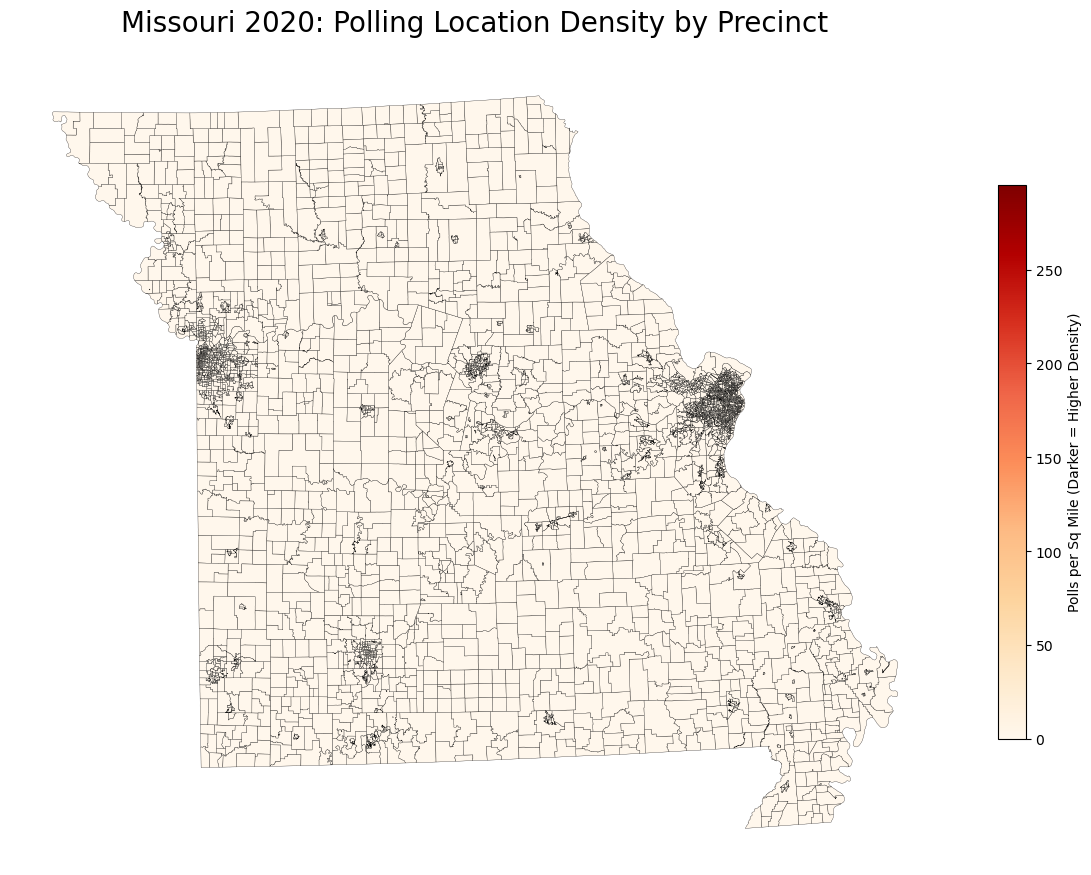

In [14]:
import matplotlib.pyplot as plt

# 1. Set up a large, high-quality canvas
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.set_title("Missouri 2020: Polling Location Density by Precinct", fontsize=20, pad=20)
ax.axis('off')

# 2. Plot using a continuous color gradient (removed scheme='quantiles')
final_precincts_gdf.plot(
    column='Polls_Per_Sq_Mile',
    ax=ax,
    cmap='OrRd',
    linewidth=0.2,
    edgecolor='black', 
    legend=True,
    legend_kwds={
        'shrink': 0.6, # Sizes the colorbar nicely on the side
        'label': 'Polls per Sq Mile (Darker = Higher Density)'
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Missing/Zero Data"
    }
)

# 3. Save and display
plt.savefig("../data/MO_2020_Density_Map_Final.png", dpi=300, bbox_inches='tight')
print("Map generated and saved as 'MO_2020_Density_Map_Final.png'!")
plt.show()

Zoomed-in map saved as 'MO_Regional_Coverage_Zoom.png'!


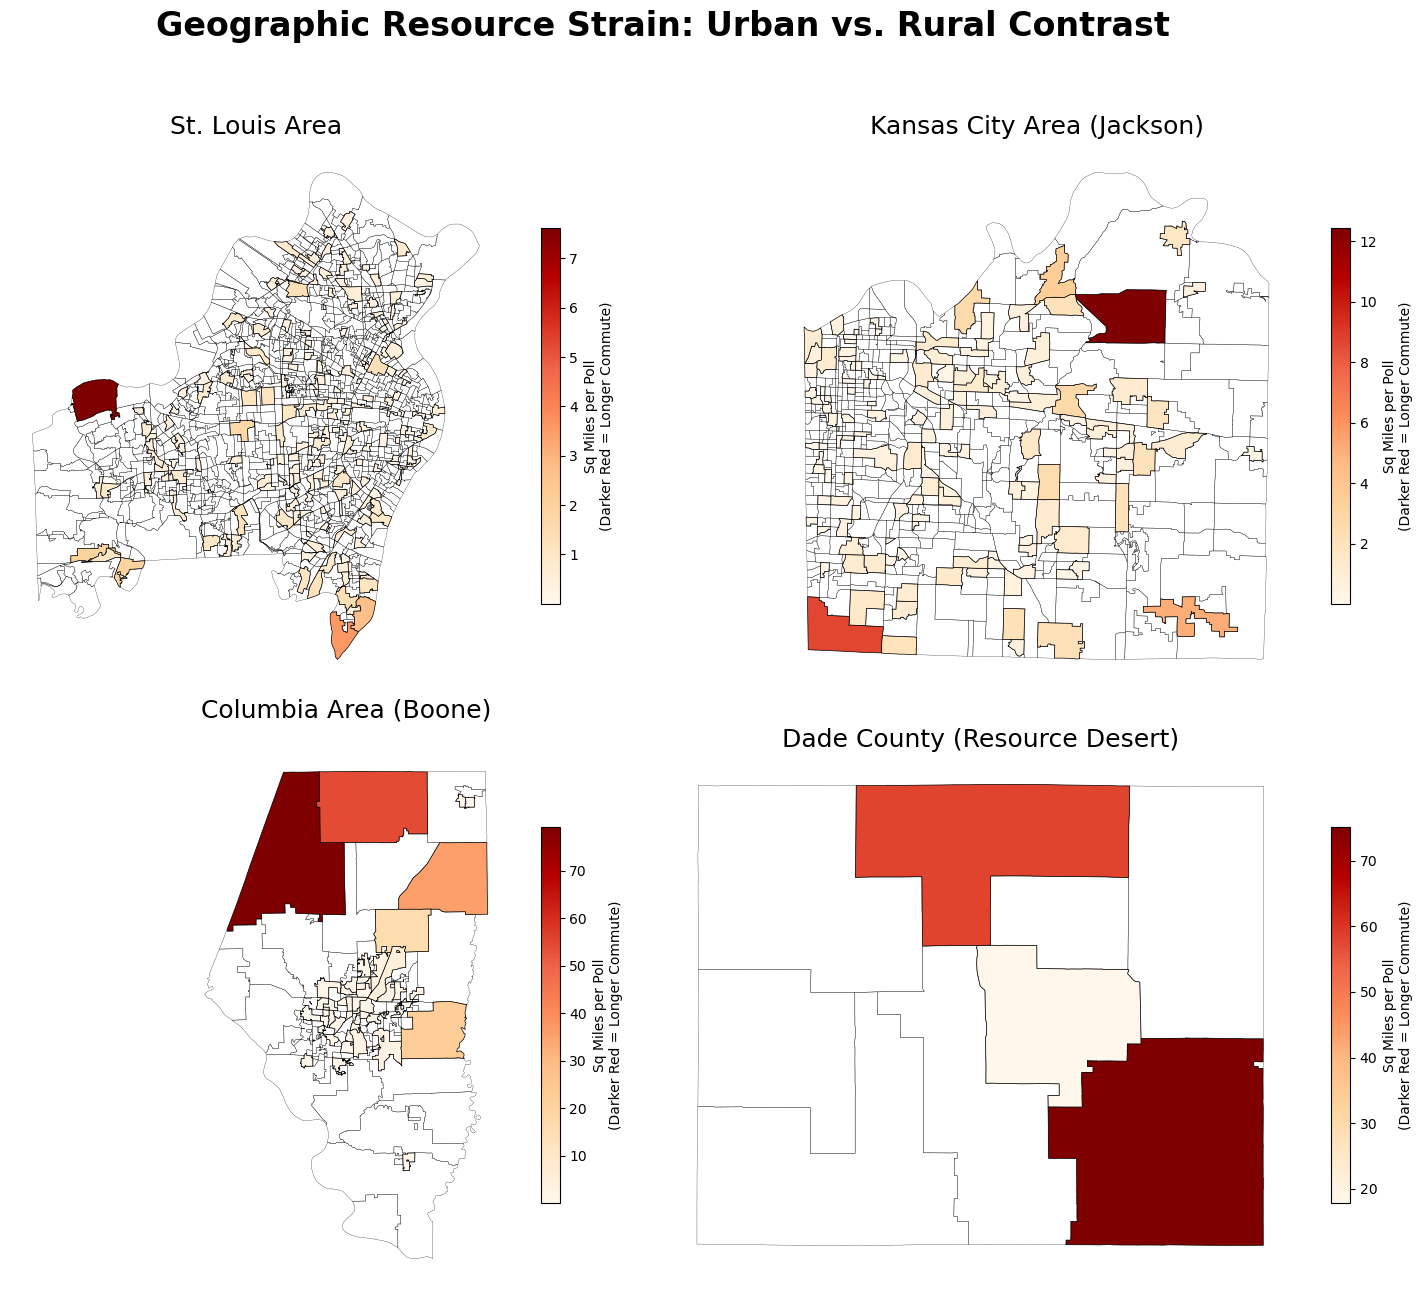

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Square Miles per Polling Place (Handling divide-by-zero)
final_precincts_gdf['Sq_Miles_Per_Poll'] = final_precincts_gdf['Area_Sq_Miles'] / final_precincts_gdf['Polling_Locations_Count'].replace(0, np.nan)

# 2. Define the regions
regions = {
    "St. Louis Area": ['189', '510'],
    "Kansas City Area (Jackson)": ['095'],
    "Columbia Area (Boone)": ['019'],
    "Dade County (Resource Desert)": ['057']
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Geographic Resource Strain: Urban vs. Rural Contrast", fontsize=24, fontweight='bold', y=0.95)
axes = axes.flatten()

# 3. Loop and Plot
for i, (title, fips_list) in enumerate(regions.items()):
    ax = axes[i]
    region_gdf = final_precincts_gdf[final_precincts_gdf['COUNTYFP20'].isin(fips_list)]
    
    region_gdf.plot(
        column='Sq_Miles_Per_Poll',
        ax=ax,
        cmap='OrRd', 
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        legend_kwds={
            'shrink': 0.7,
            'label': 'Sq Miles per Poll\n(Darker Red = Longer Commute)'
        },
        # --- THE FIX IS HERE ---
        missing_kwds={
            "color": "none",          # Makes the fill completely transparent
            "edgecolor": "black", # Fades the borders so they don't distract
            "linewidth": 0.2,
            "label": "0 Polls Mapped"
        }
    )
    
    ax.set_title(title, fontsize=18, pad=10)
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig("../data/MO_Regional_Coverage_Zoom.png", dpi=300, bbox_inches='tight', facecolor='white')

print("Zoomed-in map saved as 'MO_Regional_Coverage_Zoom.png'!")
plt.show()

Bar chart generated and saved as 'MO_Transportation_Barrier_Chart.png'!


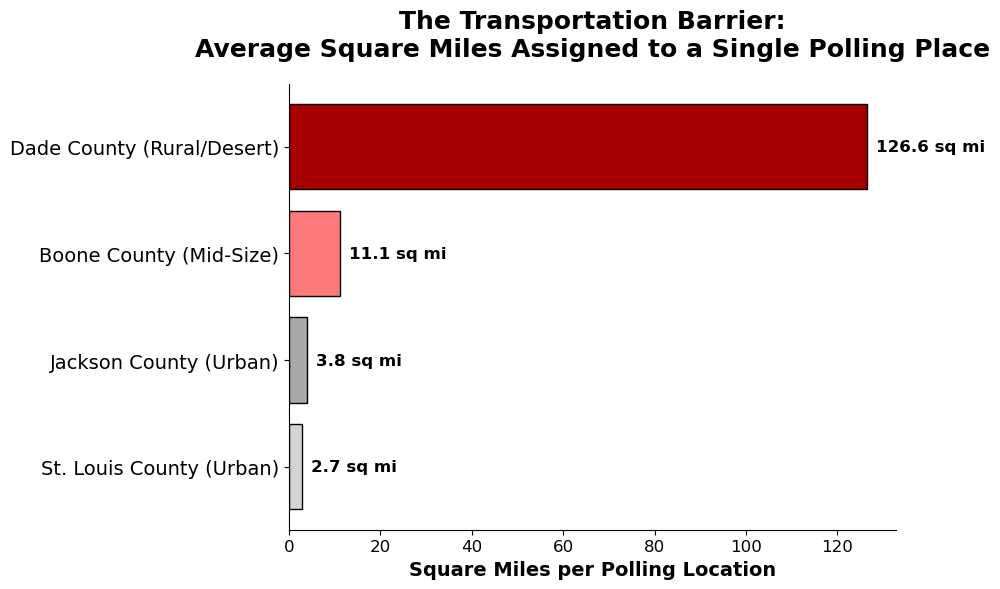

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aggregate the math to the County level
county_summary = final_precincts_gdf.groupby('COUNTYFP20').agg(
    Total_Area=('Area_Sq_Miles', 'sum'),
    Total_Polls=('Polling_Locations_Count', 'sum')
).reset_index()

# 2. Calculate the County-Wide Coverage Area
county_summary['Coverage_Area'] = county_summary['Total_Area'] / county_summary['Total_Polls']

# 3. Filter for our specific presentation counties and name them
fips_map = {
    '189': 'St. Louis County (Urban)', 
    '095': 'Jackson County (Urban)', 
    '019': 'Boone County (Mid-Size)', 
    '057': 'Dade County (Rural/Desert)'
}

chart_df = county_summary[county_summary['COUNTYFP20'].isin(fips_map.keys())].copy()
chart_df['County_Name'] = chart_df['COUNTYFP20'].map(fips_map)

# Sort from smallest to largest commute area
chart_df = chart_df.sort_values('Coverage_Area', ascending=True)

# 4. Draw a beautiful, presentation-ready Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Assign a striking color gradient (Light grey for urban, dark red for rural)
colors = ['#d3d3d3', '#a9a9a9', '#ff7b7b', '#a70000']
bars = ax.barh(chart_df['County_Name'], chart_df['Coverage_Area'], color=colors, edgecolor='black')

# 5. Formatting for PowerPoint readability
ax.set_title("The Transportation Barrier:\nAverage Square Miles Assigned to a Single Polling Place", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Square Miles per Polling Location", fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=12)

# Remove the top and right borders for a clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add the exact numbers to the end of the bars!
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f} sq mi', 
            va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("../data/MO_Transportation_Barrier_Chart.png", dpi=300, facecolor='white')

print("Bar chart generated and saved as 'MO_Transportation_Barrier_Chart.png'!")
plt.show()